In this notebook, we fit single events using LicketyFit. However, in general, one should run LicketyFit from the command line using batch_fit_driver_wcte_data.py if there are more than a few events to fit. Currently, this code runs solely on muons (fitting other particles is in process). 

In [1]:
# Get paths relative to current directory
import sys
sys.path.insert(0,"../scripts/")
sys.path.insert(0,"../tables/")
sys.path.insert(0,"../LicketyFit/")
sys.path.insert(0,"../event_display/")

# This is the module that performs single event fits to WCTE data.
# If you're wanting more customizability, open this module in /scripts
from lf_single_event import LF_single_event

from plot_event import *

#This module performs the beam cuts using the v1 data production information
from get_mu_events import *

run = 1580
n_events = 100 # Number of particle events you want to load (not just muons)

# Perform beam cuts to get a clean sample of muons
events = get_mu_events(run, n_events)



Peak-time calibration
---------------------
ROOT entries requested:        100
ROOT entries scanned:          5
Selected events used for timing scan:          50
Estimated median peak time:    1725.00 ns

Final selection
---------------
Muon-like before peak-time cut: 4
Muon-like after peak-time cut:  3



In [3]:
event_num = 2
event = events[event_num] # Choose a single muon event to fit 

Each event is comprised of an array where each element in the array corresponds to a single PMT hit. For each hit, the 0th index is the global PMT position, the 1st index is the PMT charge, the 2nd is the hit time (calibrated), and the 3rd is the event number in the original v1 production root file.

In [4]:
# Have a look at the selected event
event

array([[6006.        ,  101.        , 1700.76658772,   97.        ],
       [6000.        ,  286.        , 1718.26616043,   97.        ],
       [7600.        ,  235.        , 5601.93017523,   97.        ],
       ...,
       [5116.        ,  138.        , 1707.71314085,   97.        ],
       [5109.        ,  213.        , 1708.40615463,   97.        ],
       [5105.        ,   95.        , 1709.18609419,   97.        ]],
      shape=(350, 4))

Let's try plotting the selected event. You can use Laurence's event display code, though I have also written a scripts that connects to his code which takes in the same input as LicketyFit:

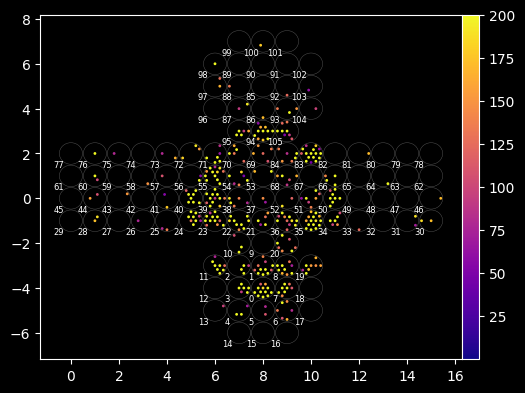

In [5]:
# Use just the PMTs, charges, and event
plot_event(event[:,0:2], event_num, vmax = 200)

Let's now try fitting this event using LicketyFit. To do this, pass the event to the LF_single_event function (contained in the lf_single_event.py file in ../scripts). It will perform further timing cuts around the central peak and will then pass the event to the core LicketyFit code to do the fit. You should get the following point estimates for each fit:

- Vertex position estimate (x0, y0, z0)
- Direction estimate (cx, cy)
- Length (this is how far the particle travels above Cherenkov threshold)
- Start time (t0)

When fitting a single event in a jupyter notebook, LicketyFit must import and construct many tables and large objects, so it will take a few seconds for results to show after running the cell below. This is one of the main reasons it is most useful to run LicketyFit from batch_fit_driver_wcte_data.py.

LicketyFit can run in multiple modes. For fastest fit results, one can use only the charge to do the fit, though including timing will generally help to constrain the fit. See the fit options in the cell below.

In [6]:
result = LF_single_event(
    event,
    fit_type="charge_time",   # "charge_only", "time_only", "charge_time"
    max_attempts=4,
    ncall=70000,
    verbose=False,
)

result["values"]

{'x0': -7.359231999014961,
 'y0': -96.29195427779496,
 'z0': -1344.9548413631317,
 'cx': -0.005717554877321134,
 'cy': -0.0015900007937827045,
 'length': 537.8747447530961,
 't0': 0.5413668193122544}